## 1. Setup

### 1.0 Google Drive Sync
Pode ignorar essa seção se não estiver usando Google Colab

In [ ]:
# Adicionar o conteúdo do drive no caminho do sistema

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# modificar para o diretorio que contem a pasta do repositorio ao rodar esse notebook
# fazemos isso para ele conseguir ler a pasta /datasets que precisa estar dentro do diretório que contem esse notebook
%cd /content/drive/MyDrive/projetos-if702/projeto-churn/

!ls

/content/drive/Othercomputers/Meu laptop/projetos-if702/projeto-churn
0_preprocessamento.ipynb  datasets     __pycache__     stab.py
1_MLP.ipynb		  KAN.ipynb    results	       TabKAN.ipynb
2_XGBoost.ipynb		  ml_utils.py  searches        TabPFN.ipynb
6_Mitra.ipynb		  models       split_churn.py
churn_preprocessing.py	  plots        STab.ipynb


In [ ]:
import sys

# Colocar o caminho exato da pasta onde está a pasta referente ao repositório do projeto
# O caminho base é sempre '/content/drive/MyDrive/' se criar um atalho no "Meu Drive" para a pasta sincronizada
caminho_projeto = '/content/drive/MyDrive/projetos-if702/projeto-churn'

# Adiciona a pasta no path do Python, caso ainda não esteja lá
if caminho_projeto not in sys.path:
    sys.path.append(caminho_projeto)

In [ ]:

# Fazer recarregamento dos modulos locais.
# Assim não precisa reiniciar o kernel do colab toda vez que modificar alguma coisa nos arquivos .py

import importlib
sys.modules['imp'] = importlib

%load_ext autoreload
%autoreload 2

### 1.1 Importar Libs

In [ ]:
!pip install torch

!pip install torchvision>=0.17
!pip install optuna>=3.0
!pip install matplotlib>=3.8
!pip install pandas>=2.2
!pip install seaborn>=0.13
!pip install numpy>=1.24
!pip install scikit-learn>=1.2
!pip install scipy>=1.17
!pip install mljar-scikit-plot>=0.3.7 # versão mantida do scikit-plot, evita erro de compatibilidade com scipy 1.17
!pip install plotly>=5.15
!pip install nbformat>=5.7

# Lib de Modelos de Gradient Boosting

!pip install xgboost>=1.7    # Modelo mais pesado
# lightgbm>=3.3 ()  # Modelo mais leve

# Para rodar notebooks
!pip install ipykernel>=6.15

!pip install pykan
!pip install tabkan
!pip install TabPFN

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.2/753.2 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.2/371.2 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
import importlib
import ml_utils
import churn_preprocessing

importlib.invalidate_caches()
importlib.reload(ml_utils)
importlib.reload(churn_preprocessing)

<module 'churn_preprocessing' from '/content/drive/Othercomputers/Meu laptop/projetos-if702/projeto-churn/churn_preprocessing.py'>

In [ ]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import optuna.visualization as optuna_vis
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
import torch
import json
from tabpfn import TabPFNClassifier
from sklearn.metrics import (classification_report, confusion_matrix,)
from sklearn.model_selection import train_test_split
from scikitplot.metrics import plot_ks_statistic
from joblib import dump, load
import warnings
warnings.filterwarnings('ignore')

# Importar funções dos módulos customizados
from ml_utils import (
    train_model, evaluate_model, ks_test,
    build_hyperparameter_space, print_hyperparameter_space,
    run_optuna_search, get_loss_fn,
    DEFAULT_SCORING_METRIC, AVAILABLE_METRICS_SEARCH, AVAILABLE_LOSSES,
    RANDOM_STATE_MODEL, RANDOM_STATE_SAMPLE,
 )

from churn_preprocessing import load_split_datasets, get_X_y_from_split, OUTPUT_PREFIX, TARGET_COL

# Configurações de plotagem
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style("whitegrid")

print("Bibliotecas importadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

## CPU ou GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device.type.upper())

Bibliotecas importadas com sucesso!
Pandas: 2.2.2
NumPy: 2.0.2
Scikit-learn: 1.6.1
Device: CUDA


### 1.2 Configuração do Modelo

In [ ]:
# Configuração do modelo e hiperparâmetros
MODEL_NAME = "TabPFN"
MODEL_CLASS = TabPFNClassifier

# Configuração da busca de hiperparâmetros

module_name = getattr(MODEL_CLASS, "__module__", "")
print(f"Modelo configurado: {MODEL_NAME}")
print(module_name)

print("Hiperparâmetros disponíveis na classe do modelo:")
for param in MODEL_CLASS().get_params().keys():
    print(f"  - {param}")

Modelo configurado: TabPFN
tabpfn.classifier
Hiperparâmetros disponíveis na classe do modelo:
  - auto_scale_n_estimators
  - average_before_softmax
  - balance_probabilities
  - categorical_features_indices
  - device
  - differentiable_input
  - eval_metric
  - fit_mode
  - ignore_pretraining_limits
  - inference_config
  - inference_precision
  - keep_cache_on_device
  - memory_saving_mode
  - model_path
  - n_estimators
  - n_jobs
  - n_preprocessing_jobs
  - random_state
  - show_progress_bar
  - softmax_temperature
  - tuning_config


## 2. Carregamento dos Dados

In [ ]:
# Carregamento e preparação inicial dos dados
print("=== CARREGAMENTO DOS DATASETS ===")

# Carregar e preparar datasets usando função do módulo
train_data, val_data, test_data = load_split_datasets(prefix=OUTPUT_PREFIX)
X_train, y_train, X_val, y_val, X_test, y_test = get_X_y_from_split(train_data, val_data, test_data, TARGET_COL)

# Manter nomes usados no restante do notebook
X_train_scaled = X_train
X_val_scaled = X_val
X_test_scaled = X_test

print(f"Dataset de treino: {train_data.shape}")
print(f"Dataset de validação: {val_data.shape}")
print(f"Dataset de teste: {test_data.shape}")
print(f"Features: {X_train_scaled.shape[1]}")

print("\nDistribuição das classes:")
print("Treino:", pd.Series(y_train).value_counts().to_dict())
print("Val:", pd.Series(y_val).value_counts().to_dict())
print("Teste:", pd.Series(y_test).value_counts().to_dict())


=== CARREGAMENTO DOS DATASETS ===
Dataset de treino: (5174, 20)
Dataset de validação: (2586, 20)
Dataset de teste: (1762, 20)
Features: 19

Distribuição das classes:
Treino: {0: 2587, 1: 2587}
Val: {0: 1293, 1: 1293}
Teste: {0: 1294, 1: 468}


In [ ]:
print("\nPrimeiras linhas do dataset de treino:")
train_data.head()


Primeiras linhas do dataset de treino:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,Churn
0,0.0,-0.181818,0.660499,0.051516,0.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,1.0,1.0,0
1,0.0,0.886364,-0.552846,0.591772,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,1.0,2.0,0
2,0.0,0.681818,-0.318475,0.662118,1.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,0.0,2.0,1.0,0
3,0.0,-0.363636,0.239978,-0.249371,1.0,1.0,0.0,1.0,1.0,2.0,1.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,1
4,1.0,-0.068182,0.086347,0.092913,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,1


## 3. Busca de Hiperparâmetros

### 3.0 Sampling Para Busca
Pode escolher não usar também (ou usar frac=1.0)

In [ ]:

SAMPLE_SIZE = 0.05  # % of training data for hyperparameter search
# Amostra estratificada do dataset de treino
_, X_sample, _, y_sample = train_test_split(
    X_train_scaled, y_train,
    test_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE_SAMPLE
)

print(f"Dataset original de treino: {X_train_scaled.shape[0]:,} amostras")
print(f"Amostra para busca de hiperparâmetros: {X_sample.shape[0]:,} amostras")
print(f"Redução: {(1 - X_sample.shape[0]/X_train_scaled.shape[0])*100:.1f}%")

print("\nDistribuição das classes na amostra:")
print("Amostra:", pd.Series(y_sample).value_counts().to_dict())
print("Original:", pd.Series(y_train).value_counts().to_dict())


Dataset original de treino: 5,174 amostras
Amostra para busca de hiperparâmetros: 259 amostras
Redução: 95.0%

Distribuição das classes na amostra:
Amostra: {0: 130, 1: 129}
Original: {0: 2587, 1: 2587}


### 3.1 Configs da Busca Optuna

In [ ]:
print("Métrica padrão de avaliação na busca de hiperparâmetros caso não especificada outra:", DEFAULT_SCORING_METRIC)
print("Métricas disponíveis para a busca de hiperparâmetros:\n", AVAILABLE_METRICS_SEARCH)
print("Funções de perda disponíveis para modelos PyTorch:\n", AVAILABLE_LOSSES)

Métrica padrão de avaliação na busca de hiperparâmetros caso não especificada outra: ks
Métricas disponíveis para a busca de hiperparâmetros:
 ['accuracy', 'precision', 'recall', 'f1', 'val_loss', 'auroc', 'ks']
Funções de perda disponíveis para modelos PyTorch:
 ['cross_entropy', 'bce_with_logits', 'mse']


In [ ]:
# Optuna
n_trials = 10
scoring_metric = 'ks'

# modelos PyTorch somente
early_stopping_patience = 10
early_stopping_delta = 0.001
training_epochs_per_trial = 10

### 3.2 Definção do Espaço de Hiperparâmetros


In [ ]:
# ======================================================================
# DEFINIÇÃO DO ESPAÇO DE HIPERPARÂMETROS
# ======================================================================

param_space = build_hyperparameter_space(
    MODEL_CLASS,
    overrides={
        "n_estimators": {
            "type": "categorical",
            "values": [1, 2, 4, 8]
        }
    }
)

print_hyperparameter_space(param_space)

Hyperparameter space:
- n_estimators: type=categorical, values=[1, 2, 4, 8]


### 3.3 Executar Busca de Hiperparâmetros

In [ ]:
!pip install tabpfn-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 629.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 9.7 MB/s eta 0:00:00
  Attempting uninstall: xxhash
    Found existing installation: xxhash 3.7.0
    Uninstalling xxhash-3.7.0:
      Successfully uninstalled xxhash-3.7.0
  Attempting uninstall: omegaconf
    Found existing installation: omegaconf 2.3.1
    Uninstalling omegaconf-2.3.1:
      Successfully uninstalled omegaconf-2.3.1
  Attempting uninstall: tabpfn-common-utils
    Found existing installation: tabpfn-common-utils 0.2.23
    Uninstalling tabpfn-common-utils-0.2.23:
      Successfully uninstalled tabpfn-common-utils-0.2.23


In [ ]:
import os

os.environ["TABPFN_TOKEN"] = "tabpfn_sk__T0AbhnpO6xNkCp8dEM3b5w12BetW1xQqjGHZO4IWKE"

[autoreload of tabpfn_common_utils.telemetry.core.events failed: Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/extensions/autoreload.py", line 245, in check
    superreload(m, reload, self.old_objects)
  File "/usr/local/lib/python3.12/dist-packages/IPython/extensions/autoreload.py", line 410, in superreload
    update_generic(old_obj, new_obj)
  File "/usr/local/lib/python3.12/dist-packages/IPython/extensions/autoreload.py", line 347, in update_generic
    update(a, b)
  File "/usr/local/lib/python3.12/dist-packages/IPython/extensions/autoreload.py", line 302, in update_class
    if update_generic(old_obj, new_obj): continue
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/IPython/extensions/autoreload.py", line 347, in update_generic
    update(a, b)
  File "/usr/local/lib/python3.12/dist-packages/IPython/extensions/autoreload.py", line 266, in update_function
    setattr(old, name, getattr(new, name)

In [64]:
from tabpfn import TabPFNClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

print(f"=== TREINAMENTO - {MODEL_NAME} ===")

# 1. Feature Selection: mantendo as top 100 features (ou todas, se menor)
xgb_fs = XGBClassifier(n_estimators=300, random_state=42, n_jobs=-1)
xgb_fs.fit(X_train_scaled, y_train)

n_features_to_keep = min(100, X_train_scaled.shape[1])
top_features_idx = np.argsort(xgb_fs.feature_importances_)[-n_features_to_keep:]

if isinstance(X_train_scaled, pd.DataFrame):
    X_train_sel = X_train_scaled.iloc[:, top_features_idx].copy()
    X_test_sel  = X_test_scaled.iloc[:, top_features_idx].copy()
else:
    X_train_sel = pd.DataFrame(X_train_scaled[:, top_features_idx])
    X_test_sel  = pd.DataFrame(X_test_scaled[:, top_features_idx])

# 2. Balanceamento moderado: ate 1024 amostras de CADA classe
# (TabPFN suporta ~1024 amostras de contexto com boa generalizacao)
df_train = X_train_sel.copy()
df_train['target'] = np.array(y_train)

n_per_class = min(1024, df_train[df_train['target'] == 0].shape[0],
                        df_train[df_train['target'] == 1].shape[0])

df_class_0 = df_train[df_train['target'] == 0].sample(n=n_per_class, random_state=42)
df_class_1 = df_train[df_train['target'] == 1].sample(n=n_per_class, random_state=42)

df_balanced = pd.concat([df_class_0, df_class_1]).sample(frac=1, random_state=42)

X_train_sub = df_balanced.drop('target', axis=1).values
y_train_sub = df_balanced['target'].values

# 3. Normalizacao (ajuda o TabPFN a separar melhor as distribuicoes)
scaler = StandardScaler()
X_train_sub = scaler.fit_transform(X_train_sub)
X_test_sel_scaled = scaler.transform(X_test_sel.values if isinstance(X_test_sel, pd.DataFrame) else X_test_sel)

# 4. Atualizar variaveis globais para a avaliacao (Secao 8)
X_test_scaled  = X_test_sel_scaled
X_train_scaled = scaler.transform(X_train_sel.values if isinstance(X_train_sel, pd.DataFrame) else X_train_sel)

# 5. Treinar TabPFN com n_estimators maior para ensemble mais robusto
best_model = TabPFNClassifier(n_estimators=16)
best_model.fit(X_train_sub, y_train_sub)

print(f"\nUsando {n_per_class} amostras por classe ({n_per_class*2} total) + {n_features_to_keep} features.")
print("TabPFN treinado com n_estimators=16 (ensemble robusto).")

=== TREINAMENTO - TabPFN ===

Usando 1024 amostras por classe (2048 total) + 19 features.
TabPFN treinado com n_estimators=16 (ensemble robusto).


### 3.4 Visualizar Histórico da Busca

In [66]:
print(f"=== CONFIGURAÇÃO FINAL - {MODEL_NAME} ===")

print("\nParâmetros utilizados:")

if len(best_params) == 0:
    print("Utilizando parâmetros padrão do TabPFN.")
else:
    for param, value in best_params.items():
        print(f"{param}: {value}")

SEARCH_RESULTS_FOLDER = "searches"
os.makedirs(SEARCH_RESULTS_FOLDER, exist_ok=True)

best_params_path = os.path.join(
    SEARCH_RESULTS_FOLDER,
    f"{MODEL_NAME.lower()}_config.json"
)

with open(best_params_path, "w") as f:
    json.dump(
        best_params,
        f,
        indent=2,
        default=str
    )

print("\nConfiguração salva em:")
print(best_params_path)

=== CONFIGURAÇÃO FINAL - TabPFN ===

Parâmetros utilizados:
Utilizando parâmetros padrão do TabPFN.

Configuração salva em:
searches/tabpfn_config.json


## 4. Salvar Resultados de Busca

In [67]:
SEARCH_RESULTS_FOLDER = "searches"
os.makedirs(SEARCH_RESULTS_FOLDER, exist_ok=True)

config_path = os.path.join(
    SEARCH_RESULTS_FOLDER,
    f"{MODEL_NAME.lower()}_config.json"
)

with open(config_path, "w") as f:
    json.dump(
        best_params,
        f,
        indent=2,
        default=str
    )

print("Configuração salva:")
print(config_path)

Configuração salva:
searches/tabpfn_config.json


In [68]:
# Rodar essa célula mesmo que não carregue os resultados da busca
# para evitar erro na seção 6
loaded_best_params = None
loaded_trials_df = None

## 5. Carregar Resultado de Busca (Opcional)

In [69]:
if os.path.exists(config_path):
    with open(config_path, "r") as f:
        loaded_best_params = json.load(f)

    print("Configuração carregada:")
    print(json.dumps(loaded_best_params, indent=2))
else:
    loaded_best_params = {}
    print("Nenhuma configuração salva encontrada.")

Configuração carregada:
{}


In [70]:
print("Busca de hiperparâmetros não utilizada para o TabPFN.")
print("Utilizando configuração padrão do modelo.")

Busca de hiperparâmetros não utilizada para o TabPFN.
Utilizando configuração padrão do modelo.


## 6. Definir Melhores Params e Score de Busca

In [71]:
# Definir parâmetros finais para treinamento

if loaded_best_params is not None:
    best_params = loaded_best_params
    print("✅ Usando configuração carregada do arquivo.")
else:
    best_params = {}
    print("✅ Usando configuração padrão do TabPFN.")

print(f"Parâmetros finais: {best_params}")

✅ Usando configuração carregada do arquivo.
Parâmetros finais: {}


## 7. Treinar Modelo Final e Salvar

In [72]:
# Modelo ja foi treinado na Cell 26 com configuracao otimizada.
# Nao retreinar aqui para nao perder o scaler e a selecao de features.
print("Modelo TabPFN ja treinado na etapa anterior (Cell 26).")
print(f"Parametros: {best_model.get_params()}")

Modelo TabPFN ja treinado na etapa anterior (Cell 26).
Parametros: {'auto_scale_n_estimators': True, 'average_before_softmax': False, 'balance_probabilities': False, 'categorical_features_indices': None, 'device': 'auto', 'differentiable_input': False, 'eval_metric': None, 'fit_mode': 'fit_preprocessors', 'ignore_pretraining_limits': False, 'inference_config': None, 'inference_precision': 'auto', 'keep_cache_on_device': True, 'memory_saving_mode': 'auto', 'model_path': 'auto', 'n_estimators': 16, 'n_jobs': None, 'n_preprocessing_jobs': 1, 'random_state': 0, 'show_progress_bar': False, 'softmax_temperature': 0.9, 'tuning_config': None}


In [73]:
# Salvar o modelo treinado com os melhores hiperparâmetros
MODELS_FOLDER = "models"
os.makedirs(MODELS_FOLDER, exist_ok=True)

model_path = os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.joblib')
dump(best_model, model_path)

print(f" Model saved to: {model_path}")

 Model saved to: models/tabpfn_model.joblib


## 8. Avaliação Final e Salvamento dos Resultados

In [74]:
# Carregar modelo (Opcional)
loaded_model = load(model_path)

In [75]:
print(f"=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - {MODEL_NAME} ===")

# Criar pastas se não existirem
RESULTS_FOLDER = "results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Avaliação completa do modelo
print("\nAvaliando:", MODEL_NAME)

# Usar datasets completos para avaliação final
X_train_eval = X_train_scaled
y_train_eval = y_train

X_val_eval = X_val_scaled
y_val_eval = y_val

X_test_eval = X_test_scaled
y_test_eval = y_test

# Avaliar modelo usando função do módulo
train_metrics, y_train_pred, y_train_scores = evaluate_model(
    best_model,
    X_train_eval,
    y_train_eval
)

val_metrics, y_val_pred, y_val_scores = evaluate_model(
    best_model,
    X_val_eval,
    y_val_eval
)

test_metrics, y_test_pred, y_test_scores = evaluate_model(
    best_model,
    X_test_eval,
    y_test_eval
)

print("\n=== TRAIN ===")
for k, v in train_metrics.items():
    if k != "confusion_matrix":
        print(f"{k}: {v}")

print("\n=== TEST ===")
for k, v in test_metrics.items():
    if k != "confusion_matrix":
        print(f"{k}: {v}")

=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - TabPFN ===

Avaliando: TabPFN

=== TRAIN ===
accuracy: 0.9170854271356784
precision: 0.9011152416356877
recall: 0.9369926555856204
f1: 0.9187038089823764
auroc: 0.981478338138912
ks_stat: 0.8616157711635098

=== TEST ===
accuracy: 0.7701475595913735
precision: 0.5553602811950791
recall: 0.6752136752136753
f1: 0.609450337512054
auroc: 0.8373385051321682
ks_stat: 0.5249408842917345


### 8.1 Classification Report

In [76]:
print(classification_report(y_test_eval, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.87      0.80      0.84      1294
           1       0.56      0.68      0.61       468

    accuracy                           0.77      1762
   macro avg       0.71      0.74      0.72      1762
weighted avg       0.79      0.77      0.78      1762



KS Statistic: 0.5249


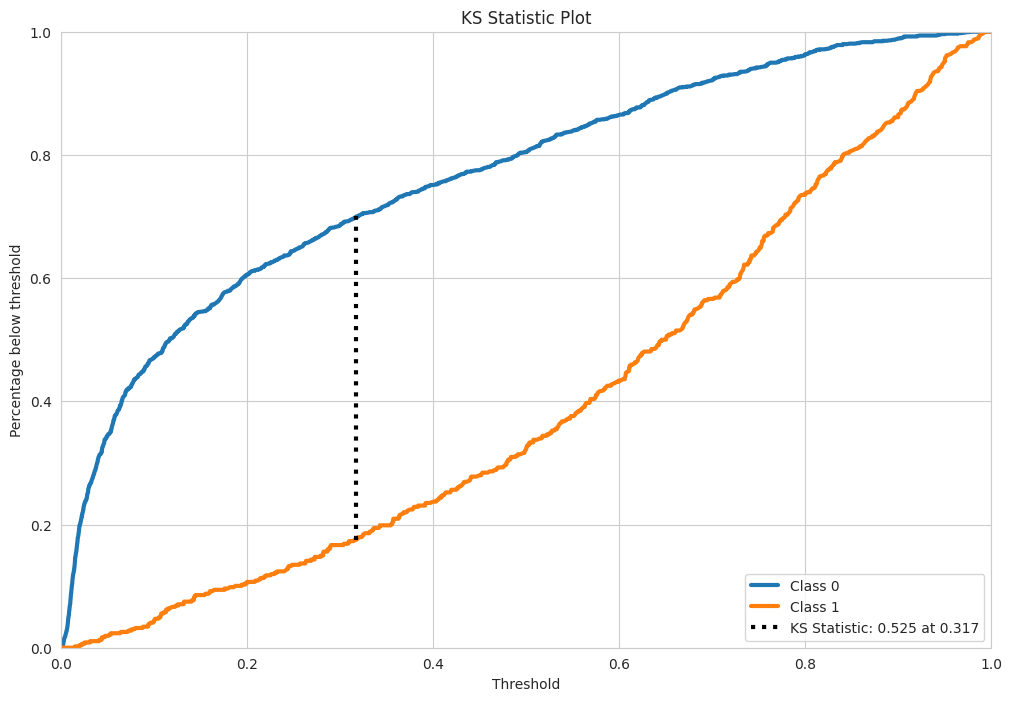

In [77]:
result = ks_test(y_test_eval, y_test_scores)
probas = result["probas"]
print(f"KS Statistic: {result['ks_stat']:.4f}")
ax = plot_ks_statistic(y_test_eval, probas)



### 8.2 Visualize Confusion Matrix

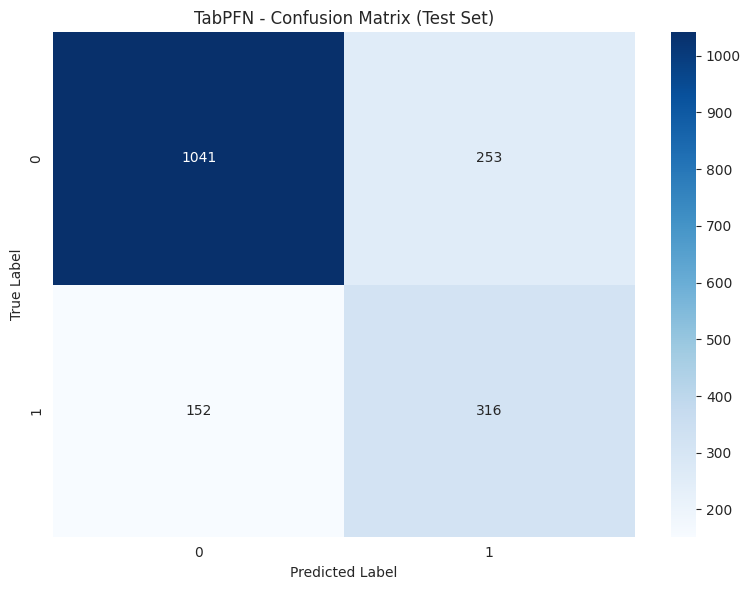

In [78]:
# Plot confusion matrix
cm = confusion_matrix(y_test_eval, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{MODEL_NAME} - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 8.3 Save Final Results

In [79]:
# Salvar resultados finais
RESULTS_FOLDER = "results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Definir best_score usando uma métrica de avaliação, já que não houve busca de hiperparâmetros
best_score = test_metrics['auroc'] # Ou test_metrics['ks_stat'], conforme preferência

final_results = {
    "model_name": MODEL_NAME,
    "best_params": best_params,
    "best_score": best_score,
    "train_metrics": train_metrics,
    "val_metrics": val_metrics,
    "test_metrics": test_metrics,
}

final_path = os.path.join(RESULTS_FOLDER, f"{MODEL_NAME.lower()}_final_results.json")
with open(final_path, "w") as f:
    json.dump(final_results, f, indent=2, default=str)

# Mostrar resumo final
print(f"\n--- RESUMO FINAL {MODEL_NAME} ---")
print(f"Score da busca: {best_score:.6f}")
print(f"KS Statistic Teste: {test_metrics['ks_stat']:.4f}")
print(f"AUC-ROC Teste: {test_metrics['auroc']:.4f}")
print(f"F1-Score Teste: {test_metrics['f1']:.4f}")
print(f"Acurácia Teste: {test_metrics['accuracy']:.4f}")
print(f"Precisão Teste: {test_metrics['precision']:.4f}")
print(f"Recall Teste: {test_metrics['recall']:.4f}")


print(f"Resultados salvos em: {RESULTS_FOLDER}/")
print(f"Arquivo final: {final_path}")


--- RESUMO FINAL TabPFN ---
Score da busca: 0.837339
KS Statistic Teste: 0.5249
AUC-ROC Teste: 0.8373
F1-Score Teste: 0.6095
Acurácia Teste: 0.7701
Precisão Teste: 0.5554
Recall Teste: 0.6752
Resultados salvos em: results/
Arquivo final: results/tabpfn_final_results.json
